# Assignment 2: Recreate a Paper
## Sharp transition towards shared vocabularies in multi-agent systems

In [7]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import itertools # use this if needed
import string

sns.set_style('darkgrid')


In [8]:
WORD_LENGTH = 5

## PlayerAgent

This class encapsulates the agents of the naming game. Each agent has a vocabulary dictinoary that stores pairs of object and their corresponding vocabs.

The has 3 methods.
* ```generate_new_word``` generates a new random word. This is used when the agent should speak but does not have any word in its vocabulary for that certain object.
* ```speak``` is called when the agent is choosen as a speaker in the interaction. It chooses a random object from the context and a random word for it from its vocabulary. If no words exist, it generates a new one and saves it.
* ```hear``` is called when the agent is chosen as a listener in the interaction. It either adds the listened word for the object to its vocabulary and returns false, or if the word matches, it clears its vocabulary apart from the one word and returns true.

In [9]:
class PlayerAgent(mesa.Agent):
    def __init__(self, model: mesa.Model, *args, **kwargs) -> None:
        super().__init__(model, *args, **kwargs)

        self.vocabulary = dict()

    def generate_new_word(self):
        new_word = "".join(random.choices(string.ascii_letters, k=WORD_LENGTH))

        return new_word

    def speak(self,context):
        current_object = random.choice(context)
        if current_object not in self.vocabulary:
            new_word = self.generate_new_word()
            self.vocabulary[current_object] = [new_word]
            self.model._add_word(new_word,current_object)
            return (current_object, new_word)
        else:
            return (current_object, random.choice(self.vocabulary[current_object]))

    def hear(self,word,current_object):
        #If the agent doesn't have any words in the vocabulary associated with the object
        if current_object not in self.vocabulary:
            self.vocabulary[current_object] = [word]
            self.model._add_word(word,current_object)
            return False
        #If the agent already has words in its vocabulary for the object, but none of them match
        elif word not in self.vocabulary[current_object]:
            self.vocabulary[current_object].append(word)
            self.model._add_word(word,current_object)
            return False
        # If one of the words in the vocabulary matches the heard word
        else:
            # On success, the agent's vocabulary for this object shrinks to the single successful word.
            old_vocab_for_obj = self.vocabulary[current_object]
            self.vocabulary[current_object] = [word]
            # Notify the model to remove the now-unused words.
            for w in old_vocab_for_obj:
                if w != word:
                    self.model._remove_word(w,current_object)
            return True

In [10]:
class Object():
    pass

class NamingGame(mesa.Model):
    def __init__(self, n_players: int, n_rounds: int, n_objects: int = 1, collect_word_dict=False):
        """This implements the naming game with a variable number of agents, rounds and objects to name"""
        super().__init__()
        self.n_agents = n_players
        self.n_rounds = n_rounds
        self.n_objects = n_objects
        self.objects = []
        self.interaction_results = None

        # Performance optimization: track word counts in the model
        self.total_words = 0
        self.word_frequencies = {}

        for _ in range(n_objects):
            self.objects.append(Object())

        for _ in range(self.n_agents):
          PlayerAgent(self)

        metrics = {
            "all_words": lambda m: m.total_words,
            "unique_words": lambda m: len(m.word_frequencies),
            "success": self.get_interaction_results,
        }
        if collect_word_dict:
            metrics["unique_word_dict"] = lambda m: dict(m.word_frequencies)

        self.datacollector = mesa.DataCollector(metrics)

    def _add_word(self, word, current_object):
        self.total_words += 1
        self.word_frequencies[(word,current_object)] = self.word_frequencies.get((word,current_object), 0) + 1

    def _remove_word(self, word, current_object):
        self.total_words -= 1
        self.word_frequencies[(word,current_object)] -= 1
        if self.word_frequencies[(word,current_object)] == 0:
            del self.word_frequencies[(word,current_object)]

    def step(self):
        self.agents.shuffle(inplace=True)
        speaker, hearer = self.agents.select(at_most=2)
        # print(f"Speaker vocab: {speaker.vocabulary}")
        # print(f"Hearer vocab: {hearer.vocabulary}")
        curr_object, word = speaker.speak(self.objects)
        # print(f"Speaker vocab after speaking: {speaker.vocabulary}")
        success = hearer.hear(word, curr_object)
        # print(f"Hearer vocab after hearing: {hearer.vocabulary}")
        # print("----------------------------------------------")
        if success:
            old_speaker_vocab = speaker.vocabulary[curr_object]
            speaker.vocabulary[curr_object] = [word]
            for w in old_speaker_vocab:
                if w != word:
                    self._remove_word(w,curr_object)


        self.interaction_results = success
        self.datacollector.collect(self)

        #Logic to turn off at convergence
        if (len(self.word_frequencies) == self.n_objects) and (self.total_words == self.n_objects * self.n_agents):
            self.running = False

    def get_interaction_results(self):
        return self.interaction_results

In [11]:
model = NamingGame(1000, None, 1)
model.run_model()

In [12]:
data = model.datacollector.get_model_vars_dataframe()

In [13]:
data['success'].mean()

np.float64(0.18311383396309475)

<Axes: ylabel='unique_words'>

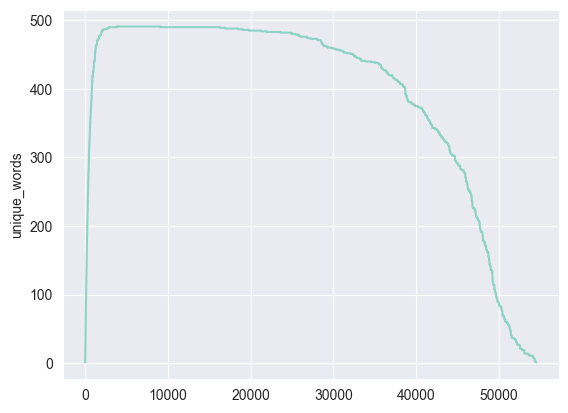

In [14]:
sns.lineplot(data['unique_words'])

<Axes: ylabel='all_words'>

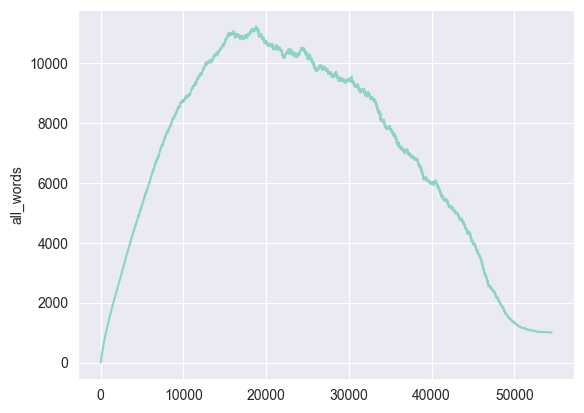

In [15]:
sns.lineplot(data['all_words'])

# Recreating fig 2

In order to recreate figure 2, we had to first setup a mechanic to run the simulation multiple times. We saved the data from each run into a list of dfs to store and use later for the visualisation.
As we were limited by our hardware and as we concluded, for statistical significance, running the model 3000 times was not necessary and the number of runs seemed to be also chosen arbitarary in the paper. In the end we concluded that 500 runs should be enough to give us pretty smooth data.

As in the paper we only run these models with one object and with 1000 agents.

In [16]:
N_AGENTS = 1000
N_RUNS = 500
N_OBJECTS = 1

def run_multiple_times(n_runs = N_RUNS,n_agents = N_AGENTS, n_objects = N_OBJECTS):
    print("Computing single run...")
    single_model = NamingGame(n_agents, None, n_objects)
    single_model.run_model()
    single_data = single_model.datacollector.get_model_vars_dataframe()

    print(f"Computing {n_runs} runs for the ensemble average...")
    all_runs_data = []
    max_steps = 0

    for i in range(n_runs):
        m = NamingGame(n_agents, None, n_objects)
        m.run_model()
        df = m.datacollector.get_model_vars_dataframe()
        all_runs_data.append(df)
        if len(df) > max_steps:
            max_steps = len(df)
    return (single_data, all_runs_data, max_steps)

single_data, all_runs_data, max_steps = run_multiple_times(N_RUNS)

Computing single run...
Computing 5 runs for the ensemble average...


This function calculates the averages of the runs. Here we had to standardize the sizing so that the averages would be calculated correctly.
1. First empty matrices were created with one dimension being the size of the longest run from the repeated simulations.
2. Then these matrices were filled with values from the simulations.
3. If a simulation ended sooner than the longest run, the rest of the matrix row was filled with maximum values possible for that metric so success would be filled with 1s for the rest of the run till max.
4. Averages were calculated over the desired metrics.

In [17]:
def count_averages(all_runs_data, max_steps, n_runs = N_RUNS, n_objects = N_OBJECTS, n_agents = N_AGENTS):
    #align for averages
    nw_matrix = np.zeros((n_runs, max_steps))
    nd_matrix = np.zeros((n_runs, max_steps))
    s_matrix = np.zeros((n_runs, max_steps))

    for i, df in enumerate(all_runs_data):
        steps = len(df)
        # Total Words
        nw_matrix[i, :steps] = df['all_words'].values
        nw_matrix[i, steps:] = n_objects * n_agents

        # Unique Words
        nd_matrix[i, :steps] = df['unique_words'].values
        nd_matrix[i, steps:] = n_objects

        # Success Rate
        s_matrix[i, :steps] = df['success'].values
        s_matrix[i, steps:] = 1.0

    # Compute mean across all runs for each time step t
    avg_nw = np.mean(nw_matrix, axis=0)
    avg_nd = np.mean(nd_matrix, axis=0)
    avg_s = pd.Series(np.mean(s_matrix, axis=0))
    return (avg_nw, avg_nd, avg_s)

avg_nw , avg_nd ,avg_s = count_averages(all_runs_data, max_steps)

This code just plots the data on a shared y axis. First the single run and then the average. ONe notable thing is the calculation of rolling average for the success rate.
In order to recreate a simple average succes rate metric at each step would not be enough as most models would en with the average success rate of around 0.2-0.3. Here we chose a rolling average at 500 steps to get the desired slow->steep->slow ascend to almost 100% that this game should demonstrate.

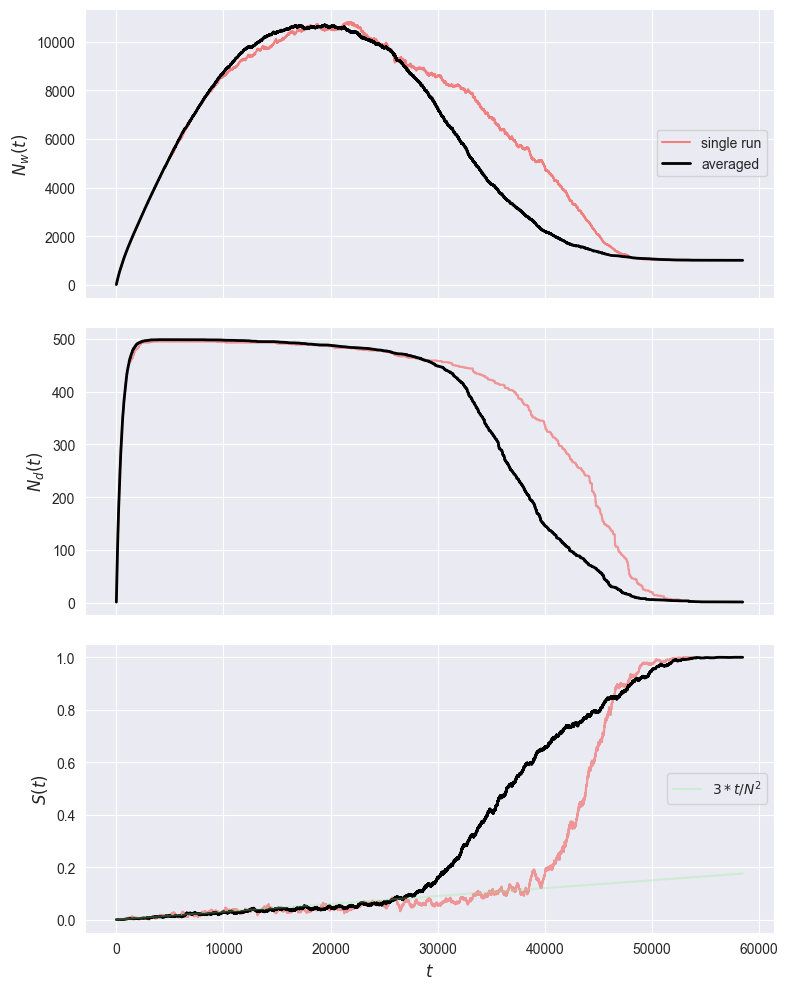

In [24]:

def plot_fig_two(single_data, avg_nw, avg_nd, avg_s):
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(single_data['all_words'], color='lightcoral', label='single run')
    axes[0].plot(avg_nw, color='black', linewidth=2, label='averaged')
    axes[0].set_ylabel('$N_w(t)$', fontsize=12)
    axes[0].legend(loc='center right')

    axes[1].plot(single_data['unique_words'], color='lightcoral', alpha=0.8)
    axes[1].plot(avg_nd, color='black', linewidth=2)
    axes[1].set_ylabel('$N_d(t)$', fontsize=12)


    # apply a rolling window here
    single_s_rolling = single_data['success'].rolling(window=500, min_periods=1).mean()
    axes[2].plot(single_s_rolling, color='lightcoral', alpha=0.8)
    axes[2].plot(avg_s.rolling(window=500, min_periods=1).mean(), color='black', linewidth=2)
    axes[2].set_ylabel('$S(t)$', fontsize=12)
    axes[2].set_xlabel('$t$', fontsize=12)
    axes[2].plot([3*x/(N_AGENTS**2) for x in range(max_steps) ], color='lightgreen', alpha=0.3,label='$3*t/N^2$')
    axes[2].legend(loc='center right')


    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1)
    plt.show()

plot_fig_two(single_data, avg_nw, avg_nd, avg_s)

As can be seen, the 500 runs smooth out the curves enough with the single runs skewig slightly from the averages. Like in the paper we have gotten:
* Max world count at around 10*N
* Max unique world count at around 0.5*N
* Beginning of success rate following the $3*t/N^2$
* The success rate follows an s shape and the success starts growing when the vocabulary reaches its tipping point.
* As in the paper, the models usually converging by 50000-60000 steps.

# Plot figure 4

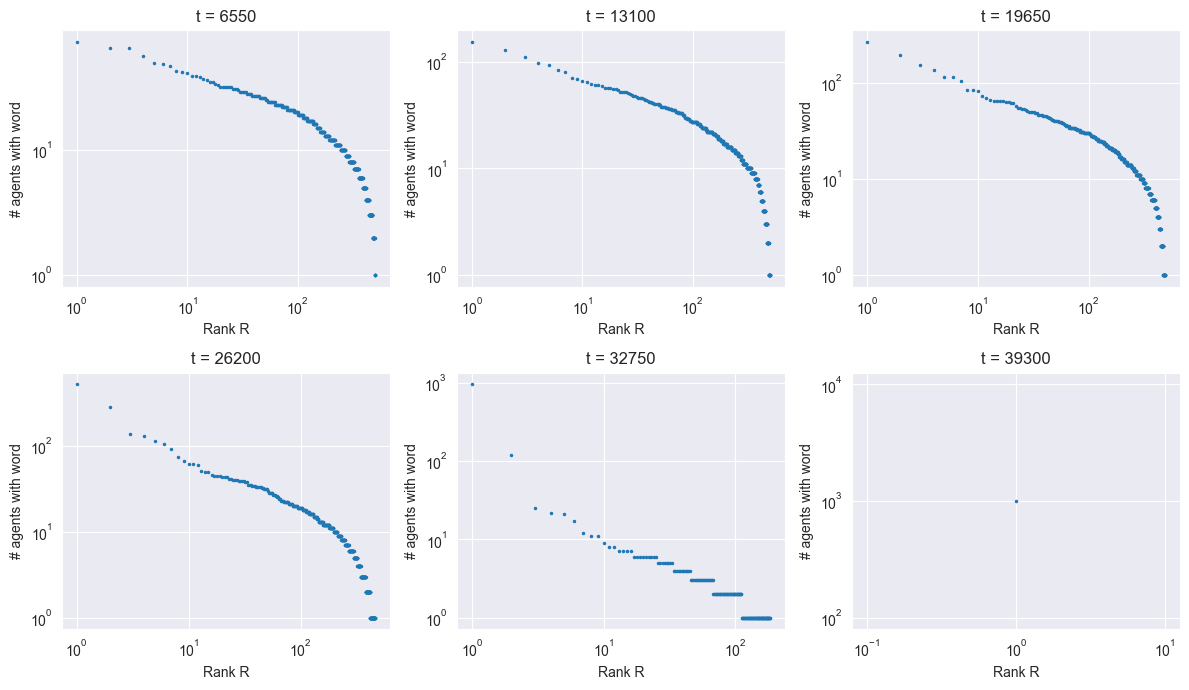

In [15]:
example_model = NamingGame(1000, None, 1, True)
example_model.run_model()
example_model = example_model.datacollector.get_model_vars_dataframe()


diff_times = [round((i+1) * (len(example_model)-1) / 6) for i in range(6)]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, step in zip(axes.flat, diff_times):
    freqs = example_model.loc[step].unique_word_dict
    counts = sorted(freqs.values(), reverse=True)
    ranks = range(1, len(counts) + 1)
    ax.loglog(ranks, counts, marker='.', markersize=3, linewidth=0)
    ax.set_title(f't = {step}')
    ax.set_xlabel('Rank R')
    ax.set_ylabel('# agents with word')

plt.tight_layout()
plt.show()